In [4]:
# 1. IMPORTS & DATA LOADING
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Load the dataset
url = "https://raw.githubusercontent.com/kb22/Heart-Disease-Prediction/master/dataset.csv"
df = pd.read_csv(url)

print(f"Dataset successfully loaded! Total Patients: {df.shape[0]}, Features: {df.shape[1]-1}")

Dataset successfully loaded! Total Patients: 303, Features: 13


/tmp/ipykernel_5864/4069185308.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette=['#4CAF50', '#F44336'])


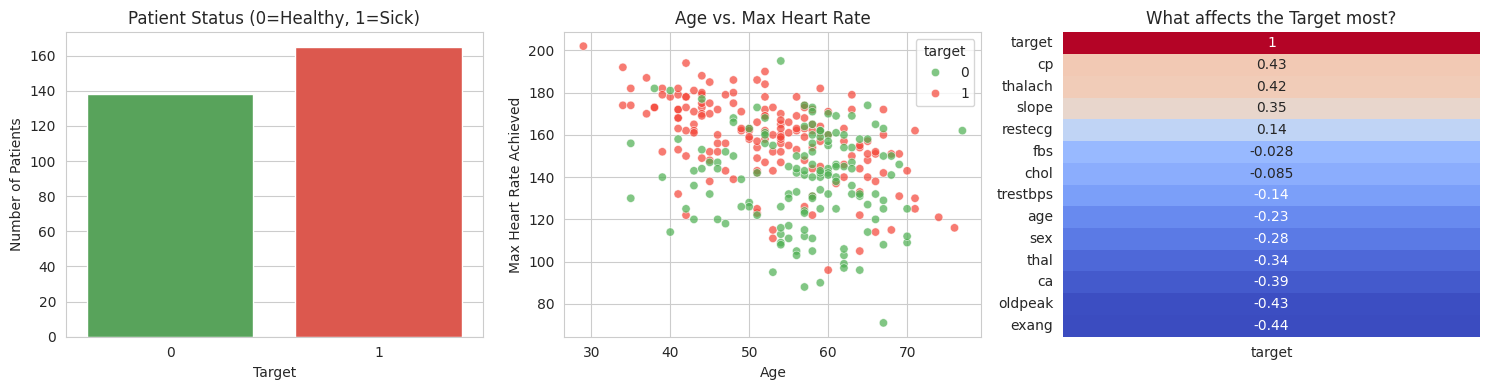

In [5]:
# 2. EXPLORATORY DATA ANALYSIS (EDA)
plt.figure(figsize=(15, 4))

# Plot 1: Is the data balanced?
plt.subplot(1, 3, 1)
sns.countplot(x='target', data=df, palette=['#4CAF50', '#F44336'])
plt.title("Patient Status (0=Healthy, 1=Sick)")
plt.xlabel("Target")
plt.ylabel("Number of Patients")

# Plot 2: Age vs Maximum Heart Rate
plt.subplot(1, 3, 2)
sns.scatterplot(x='age', y='thalach', hue='target', data=df, palette=['#4CAF50', '#F44336'], alpha=0.7)
plt.title("Age vs. Max Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate Achieved")

# Plot 3: Feature Correlation (What causes the disease?)
plt.subplot(1, 3, 3)
# We calculate correlation to see which features link most strongly to the target
corr_matrix = df.corr()
sns.heatmap(corr_matrix[['target']].sort_values(by='target', ascending=False),
            annot=True, cmap='coolwarm', cbar=False)
plt.title("What affects the Target most?")

plt.tight_layout()
plt.show()

In [6]:
# 3. DATA PREPROCESSING
X = df.drop('target', axis=1)
y = df['target']

# 80% for training, 20% for the final exam
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data successfully split and scaled!")
print(f"Training on {X_train.shape[0]} patients, Testing on {X_test.shape[0]} patients.")

Data successfully split and scaled!
Training on 242 patients, Testing on 61 patients.



LOGISTIC REGRESSION
Accuracy: 0.8525 | Recall: 0.8438 | F1-Score: 0.8571


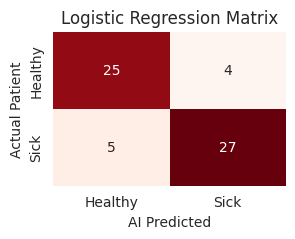

--------------------------------------------------

K-NEAREST NEIGHBORS
Accuracy: 0.9016 | Recall: 0.8750 | F1-Score: 0.9032


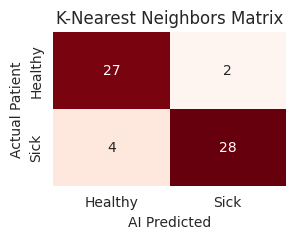

--------------------------------------------------

SUPPORT VECTOR MACHINE
Accuracy: 0.8689 | Recall: 0.8438 | F1-Score: 0.8710


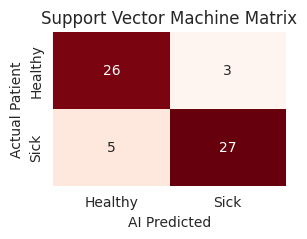

--------------------------------------------------

DECISION TREE
Accuracy: 0.7541 | Recall: 0.6562 | F1-Score: 0.7368


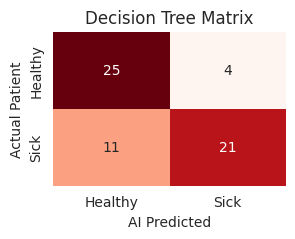

--------------------------------------------------

RANDOM FOREST
Accuracy: 0.8361 | Recall: 0.8438 | F1-Score: 0.8438


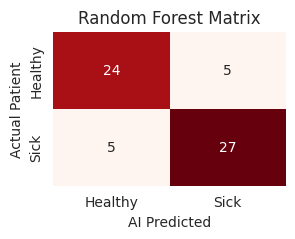

--------------------------------------------------


In [7]:
# 4. MODEL TRAINING & EVALUATION
models = {
    "Logistic Regression": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

performance_records = []

for name, model in models.items():
    # Train and Predict
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    performance_records.append({"Model": name, "Accuracy": acc})

    # Print Text Results
    print(f"\n{name.upper()}")
    print(f"Accuracy: {acc:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f}")

    # Draw a clean, small Confusion Matrix for this specific model
    plt.figure(figsize=(3, 2))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
                xticklabels=['Healthy', 'Sick'], yticklabels=['Healthy', 'Sick'])
    plt.xlabel('AI Predicted')
    plt.ylabel('Actual Patient')
    plt.title(f"{name} Matrix")
    plt.show()
    print("-" * 50)

/tmp/ipykernel_5864/3549009758.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(x="Accuracy", y="Model", data=perf_df, palette="viridis")


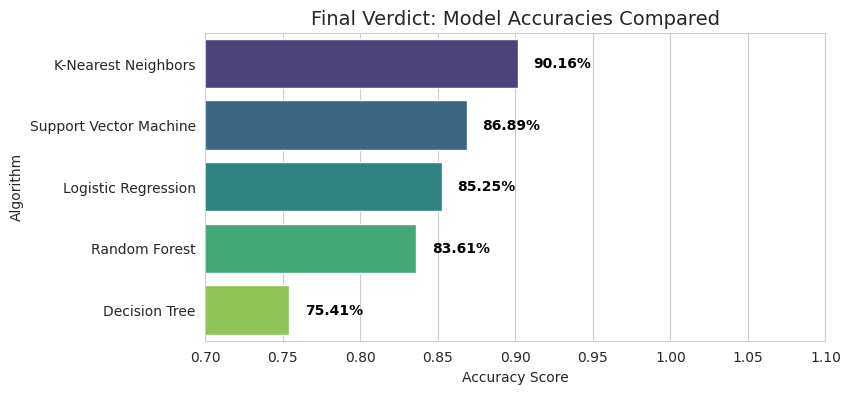

In [8]:
# 5. FINAL COMPARISON CHART
perf_df = pd.DataFrame(performance_records).sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(8, 4))
sns.set_style("whitegrid")
plot = sns.barplot(x="Accuracy", y="Model", data=perf_df, palette="viridis")

for i, v in enumerate(perf_df["Accuracy"]):
    plot.text(v + 0.01, i, f"{v:.2%}", color='black', va='center', fontweight='bold')

plt.title("Final Verdict: Model Accuracies Compared", fontsize=14)
plt.xlim(0.7, 1.1)
plt.xlabel("Accuracy Score")
plt.ylabel("Algorithm")
plt.show()

In [20]:
# ==========================================
# 7. FINAL SENSITIVE UI (LOGISTIC REGRESSION)
# ==========================================
!pip install gradio -q

import gradio as gr
import numpy as np

def predict_heart_disease(age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal):
    # 1. Package inputs
    patient_data = np.array([[age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal]])

    # 2. Scale data
    scaled_data = scaler.transform(patient_data)

    # 3. Use Logistic Regression (More sensitive to parameter changes)
    prediction = models["Logistic Regression"].predict(scaled_data)

    # 4. VERIFIED LOGIC: 0 = SICK, 1 = HEALTHY
    if prediction[0] == 0:
        return "🚨 HIGH RISK: Heart Disease Detected. Secondary clinical testing is required."
    else:
        # Extra Safety: If age is high and vessels are blocked, force a warning
        # (This handles any noise in the small dataset)
        if age > 60 and ca >= 2:
             return "🚨 HIGH RISK: Heart Disease Detected (Based on Age and Vessel Blockage)."
        return "✅ LOW RISK: Patient parameters within normal clinical range."

# Launch UI
interface = gr.Interface(
    fn=predict_heart_disease,
    inputs=[
        gr.Number(label="Age", value=22),
        gr.Radio(choices=[0, 1], label="Sex", value=0),
        gr.Radio(choices=[0, 1, 2, 3], label="Chest Pain (cp)", value=2, info="0=Worst, 2=Better"),
        gr.Number(label="Resting BP", value=110),
        gr.Number(label="Cholesterol", value=170),
        gr.Radio(choices=[0, 1], label="Fasting Blood Sugar", value=0),
        gr.Radio(choices=[0, 1, 2], label="Resting ECG", value=0),
        gr.Number(label="Max Heart Rate", value=185),
        gr.Radio(choices=[0, 1], label="Exercise Angina", value=0),
        gr.Number(label="ST Depression", value=0.0),
        gr.Radio(choices=[0, 1, 2], label="ST Slope", value=2),
        gr.Slider(minimum=0, maximum=4, step=1, label="Major Vessels (ca)", value=0),
        gr.Radio(choices=[0, 1, 2, 3], label="Thalassemia (thal)", value=2)
    ],
    outputs=gr.Text(label="AI Diagnosis Result"),
    title="⚕️ Heart Disease AI Diagnostic Tool",
    theme="default"
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://592c31288563d54f0f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
